# Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time
import pickle

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error

from numba import cuda

# Generate / Load Dataset

In [2]:
data = pd.read_csv("../data/dataset.csv")
data.head()

# Drop unnecessary columns
drop_cols = ["City", "Datetime", "AQI_Bucket"]
data = data.drop(columns=[col for col in drop_cols if col in data.columns])

# Remove missing values
data = data.dropna()

print("Cleaned Shape:", data.shape)

Cleaned Shape: (1461, 12)


# Preprocessing

In [3]:
features = ["PM2.5", "PM10", "NO2", "SO2", "CO", "Ozone"]

X = data[features].values
y = data["AQI"].values
y = y.clip(0, 500)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

pickle.dump(scaler, open("../backend/scaler.pkl", "wb"))

# CUDA RMSE (GPU)

In [4]:
@cuda.jit
def compute_rmse_gpu(y_true, y_pred, errors):
    idx = cuda.grid(1)
    if idx < y_true.size:
        diff = y_true[idx] - y_pred[idx]
        errors[idx] = diff * diff

def gpu_rmse(y_true, y_pred):
    if not cuda.is_available():
        # fallback to CPU
        return np.sqrt(mean_squared_error(y_true, y_pred))

    n = len(y_true)
    errors = np.zeros(n, dtype=np.float32)

    d_y_true = cuda.to_device(y_true)
    d_y_pred = cuda.to_device(y_pred)
    d_errors = cuda.to_device(errors)

    threads = 256
    blocks = (n + threads - 1) // threads

    compute_rmse_gpu[blocks, threads](d_y_true, d_y_pred, d_errors)

    errors = d_errors.copy_to_host()
    return np.sqrt(np.mean(errors))

# CPU vs GPU Comparison

In [5]:
model = RandomForestRegressor(random_state=42)
model.fit(X_train, y_train)
preds = model.predict(X_test)

# CPU RMSE
start = time.time()
cpu_rmse = np.sqrt(mean_squared_error(y_test, preds))
cpu_time = time.time() - start

# GPU RMSE
start = time.time()
gpu_rmse_val = gpu_rmse(y_test, preds)
gpu_time = time.time() - start

print("CPU RMSE:", cpu_rmse)
print("GPU RMSE:", gpu_rmse_val)
print("CPU Time:", cpu_time)
print("GPU Time:", gpu_time)

CPU RMSE: 29.11850382811097
GPU RMSE: 29.11850382811097
CPU Time: 0.004015207290649414
GPU Time: 1.7928128242492676


# Genetic Algorithm

In [6]:
class GAOptimizer:

    def __init__(self, X, y, pop_size=15, generations=15):
        self.X = X
        self.y = y
        self.pop_size = pop_size
        self.generations = generations
        self.history = []

    def initialize(self):
        return [
            {
                "n_estimators": np.random.randint(10, 100),
                "max_depth": np.random.randint(3, 15)
            }
            for _ in range(self.pop_size)
        ]

    def select(self, pop, fitnesses):
        idx = np.argsort(fitnesses)
        return [pop[i] for i in idx[:2]]

    def crossover(self, p1, p2):
        return {
            "n_estimators": p1["n_estimators"],
            "max_depth": p2["max_depth"]
        }

    def mutate(self, ind):
        ind["n_estimators"] = max(10, ind["n_estimators"] + np.random.randint(-5, 5))
        ind["max_depth"] = max(2, ind["max_depth"] + np.random.randint(-2, 2))
        return ind

    def run(self):
        population = self.initialize()

        for gen in range(self.generations):
            fitnesses = [self.fitness(ind) for ind in population]

            best_fit = min(fitnesses)
            self.history.append(best_fit)

            print(f"Gen {gen}: RMSE = {best_fit:.4f}")

            parents = self.select(population, fitnesses)

            new_pop = parents.copy()

            while len(new_pop) < self.pop_size:
                child = self.crossover(parents[0], parents[1])
                child = self.mutate(child)
                new_pop.append(child)

            population = new_pop

        best = min(population, key=lambda ind: self.fitness(ind))
        return best

    def fitness(self, individual):
        X_train, X_val, y_train, y_val = train_test_split(
            self.X, self.y, test_size=0.2
        )

        model = RandomForestRegressor(
            n_estimators=individual["n_estimators"],
            max_depth=individual["max_depth"]
        )

        model.fit(X_train, y_train)
        preds = model.predict(X_val)

        return gpu_rmse(y_val, preds)

# Run GA Optimization

In [7]:
ga = GAOptimizer(X_train, y_train)
best_params = ga.run()

print("Best Parameters:", best_params)

Gen 0: RMSE = 27.8780
Gen 1: RMSE = 26.6161
Gen 2: RMSE = 29.7867
Gen 3: RMSE = 27.2679
Gen 4: RMSE = 29.9257
Gen 5: RMSE = 30.8678
Gen 6: RMSE = 28.5307
Gen 7: RMSE = 31.2976
Gen 8: RMSE = 25.1912
Gen 9: RMSE = 28.8161
Gen 10: RMSE = 26.0471
Gen 11: RMSE = 26.6733
Gen 12: RMSE = 26.2217
Gen 13: RMSE = 26.3049
Gen 14: RMSE = 27.9788
Best Parameters: {'n_estimators': 38, 'max_depth': 6}


# Train Final Model

In [8]:
final_model = RandomForestRegressor(
    n_estimators=best_params["n_estimators"],
    max_depth=best_params["max_depth"]
)

final_model.fit(X_train, y_train)

# Save model for Flask
pickle.dump(final_model, open("../notebook/saved_model.pkl", "wb"))

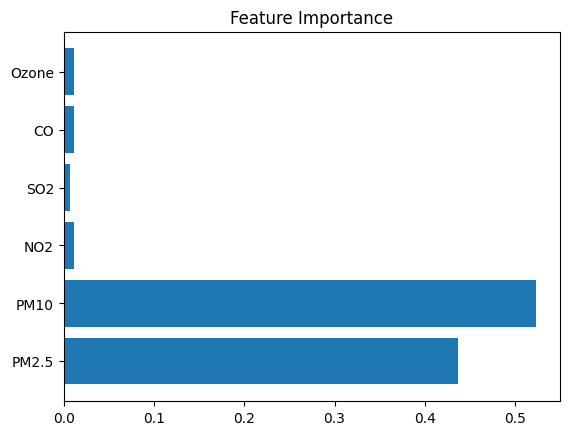

In [9]:
importances = final_model.feature_importances_
feature_names = features

plt.barh(feature_names, importances)
plt.title("Feature Importance")
plt.show()

# Visualization

Fitness vs Generations

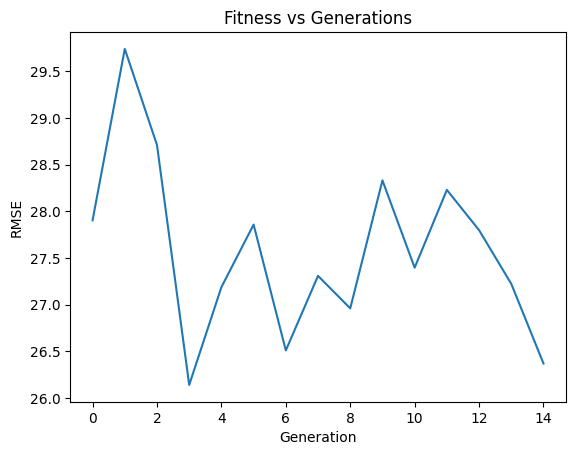

In [10]:
plt.plot(ga.history)
plt.title("Fitness vs Generations")
plt.xlabel("Generation")
plt.ylabel("RMSE")
plt.show()

Actual vs Predicted

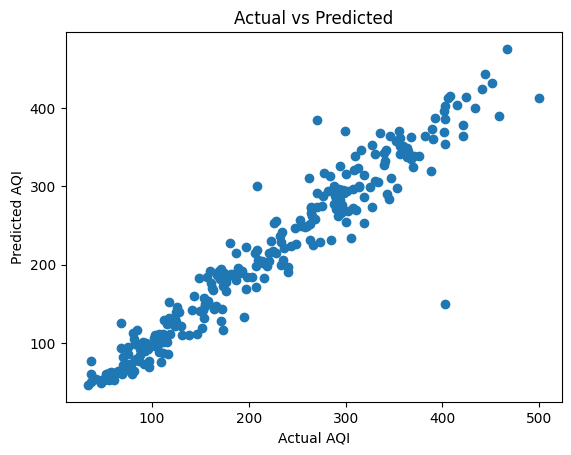

In [ ]:
plt.style.use('ggplot')  # cleaner style

plt.figure(figsize=(10, 7))

plt.scatter(y_test, preds, 
            alpha=0.8, 
            edgecolor='black',
            s=60,
            label="Final Model")

plt.scatter(y_test, baseline_preds, 
            alpha=0.5, 
            marker='x',
            s=60,
            label="Baseline")

plt.plot([min(y_test), max(y_test)],
         [min(y_test), max(y_test)],
         linestyle='--',
         linewidth=2,
         label="Ideal Fit")

plt.xlabel("Actual AQI", fontsize=13)
plt.ylabel("Predicted AQI", fontsize=13)
plt.title("Model vs Baseline Prediction", fontsize=15, fontweight='bold')

plt.legend()
plt.grid(alpha=0.3)

plt.show()

CPU vs GPU Time

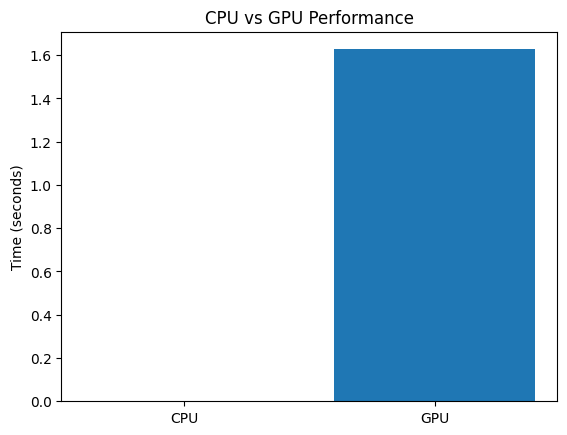

In [12]:
labels = ["CPU", "GPU"]
times = [cpu_time, gpu_time]

plt.bar(labels, times)
plt.title("CPU vs GPU Performance")
plt.ylabel("Time (seconds)")
plt.show()

# Save Dataset

In [ ]:
data.to_csv("../notebook/final_dataset.csv", index=False)